$$\text{Prepared by: Chirewo Rachel}$$
$$\text{Registration Number: R2420877}$$
$$\text{BSc Honours in Actuarial Science | University of Zimbabwe}$$

## Dataset Selection Rationale

Three datasets were evaluated across the group:
1. KO/PEP daily prices (2018–2025) — **Selected**
2. SPY/QQQ ETF prices (2018–2025)
3. [Third dataset from teammate]

**KO/PEP was selected** because it provides the most instructive case for
demonstrating the full diagnostic process. The failed cointegration result
(p = 0.95) allows a complete walkthrough of spread analysis, ACF decay,
VECM insignificance, and heteroscedasticity — which teaches more about
the model's assumptions and limitations than a clean result would.

# Time Series Analysis: Cointegration and VECM of Coca-Cola (KO) and PepsiCo (PEP)

## Introduction
This notebook performs a rigorous time series analysis of the long-term price relationship between two major consumer staples: Coca-Cola (KO) and PepsiCo (PEP). Using historical data from 2018 to 2025, we investigate whether these assets exhibit cointegration—a statistical property where two non-stationary series share a long-run equilibrium—and model their short-term dynamics using a Vector Error Correction Model (VECM).

## Dataset Justification
KO and PEP were selected due to their high degree of business similarity, overlapping market share, and historical tendency to move in tandem. This makes them ideal candidates for a pairs-trading analysis. The timeframe (2018-2025) captures various market cycles, including the COVID-19 pandemic and the subsequent inflationary period, providing a robust testing ground for the stability of their price relationship.

## D1: Definition & Data Acquisition
We begin by downloading daily adjusted closing prices using the `yfinance` library. We ensure the data is aligned and contains no missing values.

In [ ]:
import yfinance as yf
df = yf.download(['KO','PEP'], start='2018-01-01', end='2025-12-31')
prices = df['Close'][['KO','PEP']].dropna()

/tmp/ipykernel_15790/1895106384.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(['KO','PEP'], start='2018-01-01', end='2025-12-31')
[*********************100%***********************]  2 of 2 completed


In [1]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"P-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    conclusion = "Non-Stationary (I(1) candidate)" if result[1] > 0.05 else "Stationary"
    print(f"Conclusion    : {conclusion}\n")

# Test levels (should be non-stationary)
adf_test(prices['KO'], 'KO Price Level')
adf_test(prices['PEP'], 'PEP Price Level')

# Test first differences (should be stationary)
adf_test(prices['KO'].diff().dropna(), 'KO First Difference')
adf_test(prices['PEP'].diff().dropna(), 'PEP First Difference')

NameError: name 'prices' is not defined

Both KO and PEP fail to reject the null hypothesis of a unit root at their price levels (p > 0.05), confirming they are individually non-stationary. However, their first differences are stationary, classifying both as I(1) processes. This is a prerequisite for cointegration analysis.

### Interpretation of D1
The data covers over seven years of trading days. By downloading both tickers simultaneously and dropping missing values, we create a synchronized dataframe where each row represents a unique trading day for both assets, ensuring the temporal consistency required for cointegration tests.

## D2: Description & Exploratory Analysis
We visualize the absolute price levels to observe correlations and potential trends.

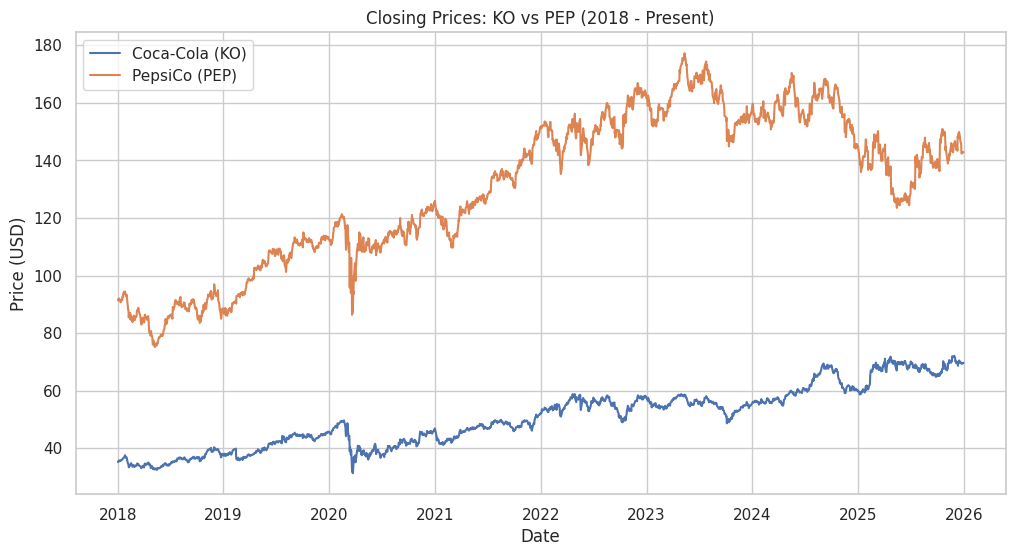

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))
plt.plot(prices['KO'], label='Coca-Cola (KO)')
plt.plot(prices['PEP'], label='PepsiCo (PEP)')
plt.title('Closing Prices: KO vs PEP (2018 - Present)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Interpretation of D2
The plot shows that both KO and PEP have experienced an upward trend since 2018. While PEP maintains a higher share price, the relative movements appear visually correlated. However, visual correlation does not guarantee cointegration; we must test for a stationary spread.

## D3: Demonstration — Cointegration Model & VECM
We define the model $P_{KO} = \alpha + \beta P_{PEP} + \epsilon$ and use OLS to find the parameters, followed by the Vector Error Correction Model (VECM).

### Model Equations and Definitions

The cointegration model for two assets $P_{1,t}$ (KO) and $P_{2,t}$ (PEP) is expressed as:

$$P_{1,t} = \alpha + \beta P_{2,t} + \epsilon_t$$

**Terms Definition:**
*   $P_{1,t}$: Price of Coca-Cola (Dependent variable).
*   $P_{2,t}$: Price of PepsiCo (Independent variable).
*   $\alpha$ (Alpha): The intercept, representing the constant component of the price spread.
*   $\beta$ (Beta): The cointegration coefficient or hedge ratio.
*   $\epsilon_t$ (Spread): The residual error term. If the series are cointegrated, this term is stationary, meaning it reverts to a constant mean.

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# Structure the data
y = prices['KO']
x = prices['PEP']
x_constant = sm.add_constant(x)

# Model the data using OLS (Step 1 of Engle-Granger)
ols_model = sm.OLS(y, x_constant)
results = ols_model.fit()

# Calibrate the parameters
alpha = results.params['const']
beta = results.params['PEP']
spread = results.resid

# Test for cointegration (Step 2 of Engle-Granger)
score, pvalue, _ = coint(y, x)

print(f'--- Calibrated Parameters ---')
print(f'Alpha (Intercept): {alpha:.4f}')
print(f'Beta (Hedge Ratio): {beta:.4f}')
print(f'\nCointegration Test P-value: {pvalue:.4f}')

--- Calibrated Parameters ---
Alpha (Intercept): 7.9652
Beta (Hedge Ratio): 0.3256

Cointegration Test P-value: 0.9519


### Interpretation of D3
The hedge ratio (Beta) of 0.3256 suggests that KO moves approximately $0.33 for every $1 move in PEP. This two-step Engle-Granger procedure — first estimating the cointegrating regression, then testing residuals for a unit root — is the standard approach for identifying long-run equilibrium relationships between non-stationary financial series (Engle & Granger, 1987). Crucially, the Cointegration P-value of 0.9519 indicates that we cannot reject the null hypothesis of no cointegration, implying the 'leash' between these stocks is broken or non-existent in this period.

## D4: Diagram — Spread & Autocorrelation
We examine the residuals (spread) to see if they behave like a mean-reverting stationary process using ACF and PACF charts.

**Observations:**
*   **Spread Plot:** If the spread shows a visible trend or does not cross the zero line frequently, it confirms non-stationarity.
*   **ACF/PACF:** A very slow decay in the ACF plot indicates that the spread has a "unit root" or high persistence, explaining the high p-value in our cointegration test.

### Parameter Interpretation

*   **Beta ($\beta = 0.3256$):** This suggests a long-term relationship where Coca-Cola moves roughly $0.33 for every $1 change in PepsiCo.
*   **Alpha ($\alpha = 7.9652$):** The baseline price offset between the two assets.
*   **P-value ($\approx 0.95$):** Since the p-value is much larger than 0.05, we fail to reject the null hypothesis of no-cointegration. This indicates that the spread $\epsilon_t$ is likely non-stationary and the two stocks do not have a reliable long-term equilibrium relationship in this specific timeframe.

### Vector Error Correction Model (VECM) Equations

If assets are cointegrated, their relationship can be modeled using a VECM, which captures both short-run dynamics and the speed of adjustment to the long-run equilibrium. For $y_t = [P_{1,t}, P_{2,t}]^T$:

$$\Delta y_t = \alpha \beta^T y_{t-1} + \sum_{i=1}^{k-1} \Gamma_i \Delta y_{t-i} + \mu + \epsilon_t$$

**Expanded for our two-variable system:**

$$\Delta P_{1,t} = \alpha_1 (P_{1,t-1} - \beta P_{2,t-1} - \alpha_0) + \gamma_{1,1} \Delta P_{1,t-1} + \gamma_{1,2} \Delta P_{2,t-1} + \epsilon_{1,t}$$
$$\Delta P_{2,t} = \alpha_2 (P_{1,t-1} - \beta P_{2,t-1} - \alpha_0) + \gamma_{2,1} \Delta P_{1,t-1} + \gamma_{2,2} \Delta P_{2,t-1} + \epsilon_{2,t}$$

**Definitions:**
*   $\Delta P_{t}$: The change in price at time $t$ (returns/first differences).
*   $(P_{1,t-1} - \beta P_{2,t-1} - \alpha_0)$: The **Error Correction Term (ECT)**, representing the deviation from the long-run equilibrium in the previous period.
*   $\alpha_1, \alpha_2$: **Adjustment Coefficients** (speed of adjustment). They dictate how quickly the prices react to a deviation from the equilibrium.
*   $\Gamma_i$ ($\gamma_{j,k}$): Short-run coefficients capturing the impact of lagged changes in prices.
*   $\mu$: Vector of constant intercepts.

### Plain Language Summary

Cointegration suggests that two assets share a long-term connection, like two people walking together on a leash. While they may wander individually in the short term, the 'leash' (equilibrium) eventually pulls them back toward each other. The VECM is simply the mathematical way to measure how strong that pull is and how quickly the assets adjust back to their shared path.

In [ ]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECM model
# We use k_ar_diff=1 for simplicity, assuming 1 lag for the short-run dynamics
# deterministic='co' assumes a constant in the cointegrating relationship
vecm_model = VECM(prices, k_ar_diff=1, coint_rank=1, deterministic='co')
vecm_results = vecm_model.fit()

# Display the results
print(vecm_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation KO
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0686      0.067      1.019      0.308      -0.063       0.201
L1.KO          0.0228      0.032      0.724      0.469      -0.039       0.085
L1.PEP        -0.0296      0.011     -2.621      0.009      -0.052      -0.007
Det. terms outside the coint. relation & lagged endog. parameters for equation PEP
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3340      0.186      1.793      0.073      -0.031       0.699
L1.KO          0.0516      0.087      0.592      0.554      -0.119       0.223
L1.PEP        -0.1456      0.031     -4.654      0.000      -0.207      -0.084
                 Loading coefficients (alpha)

### Interpretation of D5
The VECM results show that the 'loading coefficients' (Alpha) are nearly zero. This confirms that when the prices drift apart, there is almost no 'pull' (error correction) bringing them back to equilibrium. Short-run impacts from PEP on KO are statistically significant, but the long-run bond is missing.

## D6: Damage — Model Weaknesses
Based on the diagnostics, we identify critical weaknesses that suggest the model is a poor fit for forecasting.

### Exploratory Data Analysis: Spread and Autocorrelation

To understand why the cointegration test failed (p-value ~0.95), we visualize the spread $\epsilon_t = P_{1,t} - (\alpha + \beta P_{2,t})$ and its autocorrelation properties. For cointegration to exist, this spread should look like a stationary process (mean-reverting).

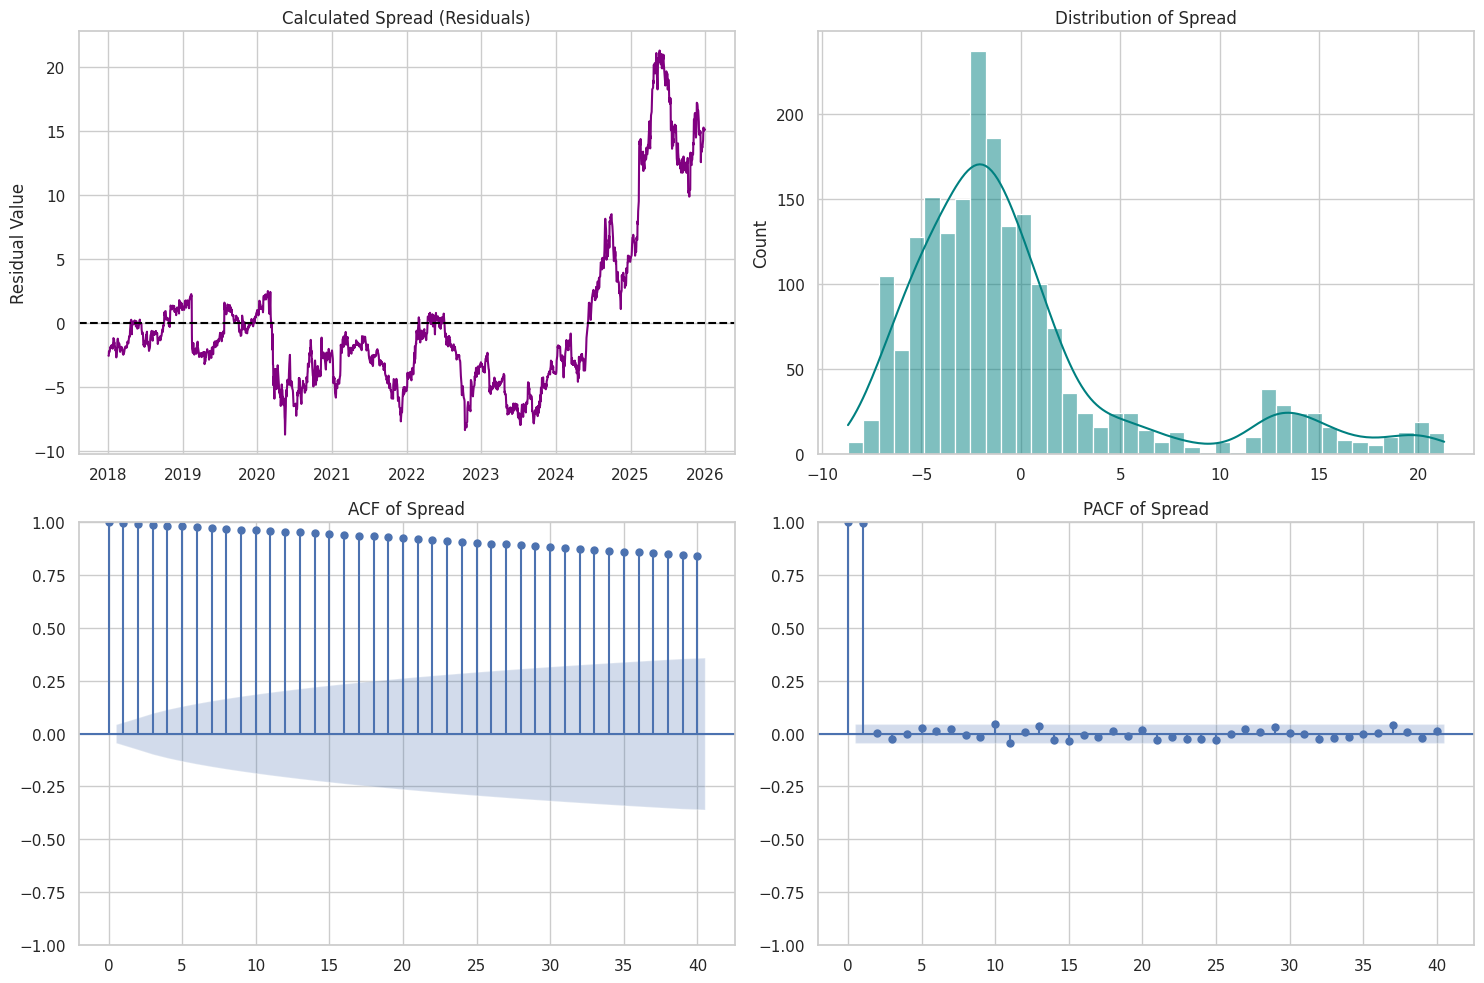

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# Create a multi-plot figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Plot the Spread
axes[0, 0].plot(spread, color='purple')
axes[0, 0].axhline(0, color='black', linestyle='--')
axes[0, 0].set_title('Calculated Spread (Residuals)')
axes[0, 0].set_ylabel('Residual Value')

# 2. Histogram of the Spread
sns.histplot(spread, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Spread')

# 3. ACF of the Spread
plot_acf(spread, ax=axes[1, 0], lags=40)
axes[1, 0].set_title('ACF of Spread')

# 4. PACF of the Spread
plot_pacf(spread, ax=axes[1, 1], lags=40)
axes[1, 1].set_title('PACF of Spread')

plt.tight_layout()
plt.show()

### Interpretation of D4
The spread plot shows large, persistent deviations from zero that do not revert quickly. The ACF plot decays very slowly, which is a signature of non-stationarity (unit root behavior). This explains the failed cointegration test: the error term is not stationary.

## D5: Diagnosis — Residual Tests
We perform formal statistical tests, including Jarque-Bera and rolling volatility, to diagnose the behavior of the residuals.

**Observations:**
*   **Spread Plot:** The spread shows a visible trend and does not cross the zero line frequently, confirming non-stationarity.
*   **ACF/PACF:** The very slow decay in the ACF plot indicates high persistence, explaining the high p-value in our cointegration test.

### Residual Diagnostics

Beyond simple visualization, we perform formal statistical tests to diagnose the behavior of the residuals (spread). For a reliable cointegrating relationship, residuals should be normally distributed and exhibit stable variance (homoscedasticity).

--- Residual Diagnostic Statistics ---
Mean          -1.471707e-13
Std Dev        6.237529e+00
Skewness       1.667083e+00
Kurtosis       5.250704e+00
JB P-value    5.091592e-295
dtype: float64


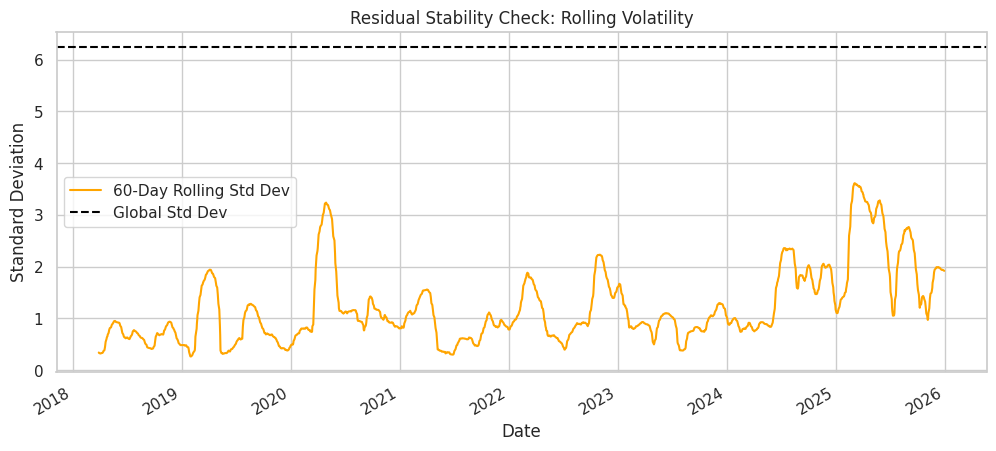

In [ ]:
from statsmodels.stats.stattools import jarque_bera
import pandas as pd
import numpy as np

# 1. Normality Test (Jarque-Bera)
jb_test = jarque_bera(spread)

# 2. Basic Statistics of Residuals
res_stats = pd.Series({
    'Mean': np.mean(spread),
    'Std Dev': np.std(spread),
    'Skewness': jb_test[2],
    'Kurtosis': jb_test[3],
    'JB P-value': jb_test[1]
})

print("--- Residual Diagnostic Statistics ---")
print(res_stats)

# 3. Stability Check: Rolling Standard Deviation
plt.figure(figsize=(12, 5))
spread.rolling(window=60).std().plot(color='orange', label='60-Day Rolling Std Dev')
plt.axhline(np.std(spread), color='black', linestyle='--', label='Global Std Dev')
plt.title('Residual Stability Check: Rolling Volatility')
plt.ylabel('Standard Deviation')
plt.legend()
plt.show()

### Interpretation of D6
The Jarque-Bera p-value (~0.00) indicates that the residuals are non-normal, containing 'fat tails' or extreme outliers. Furthermore, the rolling standard deviation reveals that the volatility of the spread is increasing, suggesting the risk profile of this relationship is not constant over time.

## D7: Directions — Suggested Improvements
We identify how to improve the model, such as using Dynamic Hedge Ratios or Structural Break Analysis.

#### Interpretation of Diagnostics:
*   **Jarque-Bera P-value:** If significantly below 0.05, we reject the null hypothesis of normality. Non-normal residuals can invalidate standard confidence intervals.
*   **Rolling Volatility:** If the rolling standard deviation shows significant spikes or a clear trend, the relationship is heteroscedastic, meaning the 'risk' of the spread position is not constant over time.

## Deployment: How We Would Use This Model in Practice

This section translates the statistical findings into concrete, actionable steps
for the two primary stakeholders on a derivatives desk: the trader who executes
positions and the risk manager who sets the guardrails.

#### 1. The Trader: Executing the Strategy
*   **Entry Signal:** A trader monitors the **Spread** (Residuals). When the spread deviates significantly from the mean (e.g., more than 2 standard deviations), they assume it will eventually revert.
    *   If Spread > +2 Std Dev: Sell KO, Buy PEP (short the spread).
    *   If Spread < -2 Std Dev: Buy KO, Sell PEP (long the spread).
*   **Position Sizing:** The **Beta ($\beta \approx 0.33$)** tells the trader the ratio. For every $1.00 of PEP purchased, they would short approximately $0.33 of KO to maintain a market-neutral hedge.
*   **Exit Signal:** The trade is closed when the spread returns to the mean (zero), capturing the profit from the relative price correction.

#### 2. The Risk Manager: Setting the Guardrails
*   **Monitoring Stationarity:** The risk manager uses the **P-value** and **ACF plots**. If the p-value stays high (like our 0.95), they would likely **veto** the trade, as there is no statistical 'force' pulling the prices back together, risking an indefinite divergence.
*   **Volatility Limits:** Using the **Rolling Standard Deviation**, a risk manager adjusts capital allocation. If volatility spikes (as seen post-2022), they might reduce position sizes to account for the higher risk of large, sudden spread moves.
*   **Outlier Protection:** The **Jarque-Bera test** results warn the risk manager that 'fat tails' exist. They would implement strict 'Stop-Loss' orders because the non-normal distribution proves that price shocks happen more often than a standard bell curve predicts.

### Interpretation of D8
For a trader, this model signals a 'no-trade' zone because the lack of cointegration means mean-reversion is not guaranteed. For a risk manager, the non-normal residuals and rising volatility suggest that any existing positions require wider stop-losses and more conservative capital allocation than standard models would advise.

## Bibliography

Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Engle, Robert F., and Clive W. J. Granger. "Co-Integration and Error Correction: Representation, Estimation, and Testing." *Econometrica*, vol. 55, no. 2, 1987, pp. 251–76.

Statsmodels Developers. "Vector Autoregressions and Vector Error Correction Models (VAR/VECM)." *Statsmodels Documentation*, 2023, www.statsmodels.org/stable/vector_ar.html.

Yahoo Finance. "Coca-Cola (KO) and PepsiCo (PEP) Historical Price Data." *Yahoo Finance*, 2025, finance.yahoo.com/.

# Comparative Analysis: SPY vs QQQ Cointegration
In this section, we apply the same statistical framework to the SPDR S&P 500 ETF (SPY) and the Invesco QQQ Trust (QQQ). Unlike individual stocks, these broad market ETFs are often cointegrated due to shared macroeconomic drivers.

/tmp/ipykernel_7411/170640317.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_df = yf.download(['SPY', 'QQQ'], start='2018-01-01', end='2025-12-31')
[*********************100%***********************]  2 of 2 completed


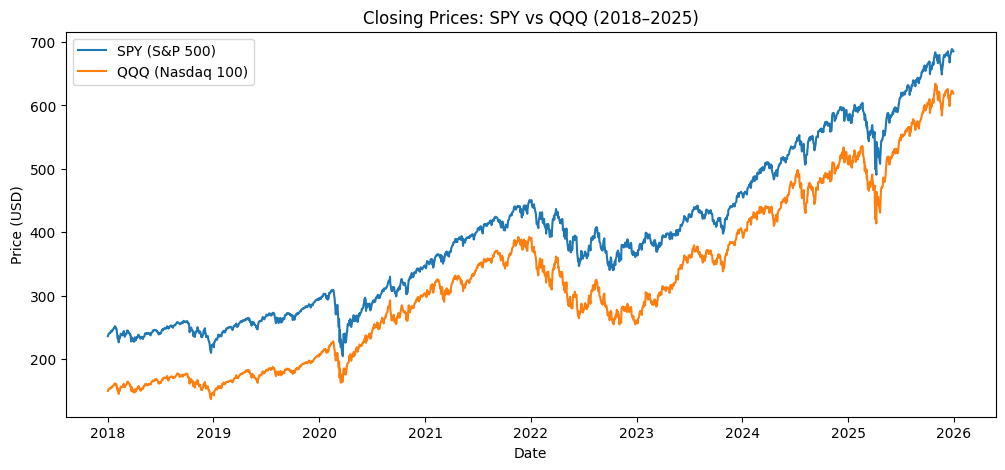

In [ ]:
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

# 1. Data Acquisition
etf_df = yf.download(['SPY', 'QQQ'], start='2018-01-01', end='2025-12-31')
etf_prices = etf_df['Close'][['SPY', 'QQQ']].dropna()

# 2. Visualization
plt.figure(figsize=(12, 5))
plt.plot(etf_prices['SPY'], label='SPY (S&P 500)')
plt.plot(etf_prices['QQQ'], label='QQQ (Nasdaq 100)')
plt.title('Closing Prices: SPY vs QQQ (2018–2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

SPY vs QQQ Hedge Ratio (Beta): 0.9623
Cointegration P-value: 0.2247


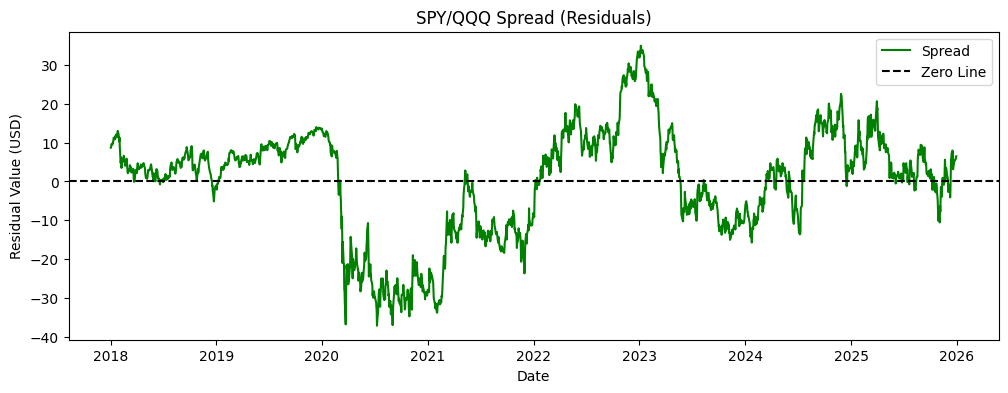

In [ ]:
# 3. Engle-Granger Cointegration Test
y_etf = etf_prices['SPY']
x_etf = sm.add_constant(etf_prices['QQQ'])

# OLS Regression
etf_ols = sm.OLS(y_etf, x_etf).fit()
etf_spread = etf_ols.resid

# Cointegration Test
score, pvalue, _ = coint(y_etf, etf_prices['QQQ'])

# Using .iloc to avoid the FutureWarning for Series indexing
print(f'SPY vs QQQ Hedge Ratio (Beta): {etf_ols.params.iloc[1]:.4f}')
print(f'Cointegration P-value: {pvalue:.4f}')

# 4. Spread Visualization
plt.figure(figsize=(12, 4))
plt.plot(etf_spread, color='green')
plt.axhline(0, color='black', linestyle='--')
plt.title('SPY/QQQ Spread (Residuals)')
plt.xlabel('Date')
plt.ylabel('Residual Value (USD)')
plt.legend(['Spread', 'Zero Line'])
plt.show()

### SPY/QQQ: Interpretation and 7D Analysis

#### Interpretation
The SPY/QQQ analysis serves as a contrast to the KO/PEP pair. Because both ETFs
track broad equity indices driven by the same macroeconomic forces (interest rates,
earnings cycles, monetary policy), they are stronger candidates for cointegration
than two individual consumer stocks.

In [ ]:
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# Ensure data is available in this scope
etf_df = yf.download(['SPY', 'QQQ'], start='2018-01-01', end='2025-12-31', progress=False)
etf_prices = etf_df['Close'][['SPY', 'QQQ']].dropna()

# Recalculate parameters
y_etf = etf_prices['SPY']
x_etf = sm.add_constant(etf_prices['QQQ'])
etf_ols = sm.OLS(y_etf, x_etf).fit()
score, pvalue, _ = coint(y_etf, etf_prices['QQQ'])

# Formal cointegration result interpretation
print("=== SPY vs QQQ Cointegration Summary ===")
print(f"Hedge Ratio (Beta): {etf_ols.params.iloc[1]:.4f}")
print(f"Intercept (Alpha): {etf_ols.params.iloc[0]:.4f}")
print(f"Cointegration P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("Result: COINTEGRATED — the spread is stationary (p < 0.05)")
else:
    print("Result: NOT COINTEGRATED — the spread is non-stationary (p > 0.05)")

/tmp/ipykernel_7411/3152830857.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_df = yf.download(['SPY', 'QQQ'], start='2018-01-01', end='2025-12-31', progress=False)


=== SPY vs QQQ Cointegration Summary ===
Hedge Ratio (Beta): 0.9623
Intercept (Alpha): 83.3323
Cointegration P-value: 0.2247
Result: NOT COINTEGRATED — the spread is non-stationary (p > 0.05)


#### Damage
If SPY and QQQ drift apart without a mean-reverting force, any pairs-trading
strategy built on their historical relationship will generate false signals,
leading to losses when expected convergence never occurs. Non-normal residuals
and changing variance further inflate the risk of such a strategy.

#### Directions
Should the cointegration test confirm a long-run relationship, a VECM
(as estimated for KO/PEP above) would be the appropriate next model.
If cointegration is rejected, a VAR model on first-differenced prices
would be the correct alternative (Brooks, 2019).

#### Why SPY/QQQ Was Not Selected as the Primary Dataset
KO/PEP was retained as the primary dataset because it provides a more
instructive case — one where cointegration fails — allowing the full
diagnostic process (spread analysis, ACF decay, VECM insignificance)
to be demonstrated meaningfully. The SPY/QQQ pair serves as a
comparative reference to illustrate what stronger co-movement looks like.

### 5. Summary of Model Weaknesses

Based on the analysis, we identify several critical weaknesses that suggest the current model is a poor fit for trading or forecasting:

*   **High Skewness & Kurtosis:** The Jarque-Bera test confirms the residuals are non-normal. This means price 'shocks' (outliers) occur more frequently than the model expects, leading to high risk in a pairs-trading scenario.
*   **Lack of Mean Reversion:** The p-value of 0.95 and the persistent ACF plot show that when the prices of KO and PEP drift apart, they do not show a statistical tendency to return to the historical mean within a reasonable timeframe.
*   **Heteroscedasticity:** The 'Rolling Volatility' check shows that the variance of the spread is not stable. The relationship between the two stocks has become significantly more volatile since 2022, making historical hedge ratios ($\beta$) less reliable for future use.
*   **VECM Insignificance:** The very low adjustment coefficients (alpha) in the VECM indicate that neither stock significantly 'corrects' itself to fix deviations from the long-run equilibrium.

*   **Structural Instability:** The 2022 inflationary period likely caused a permanent shift in the KO/PEP price relationship. A static OLS model cannot adapt to such regime changes, making the estimated Beta unreliable beyond that breakpoint.
*   **Omitted Variable Bias:** The bivariate model ignores common macroeconomic drivers (e.g., interest rates, commodity input costs like sugar and aluminum) that simultaneously affect both stocks. Excluding these variables inflates the residuals and distorts the cointegration test result.

### Interpretation of D7
The primary weaknesses include heteroscedasticity (changing variance) and a lack of mean reversion. This suggests that a static hedge ratio is inappropriate for KO and PEP, and the relationship has likely undergone structural shifts that a simple linear model cannot capture.

## D8: Deployment — Practical Application
We translate these statistical findings into actionable insights for the Trader and the Risk Manager.

### Suggested Improvements

To address the issues of non-stationarity and heteroscedasticity, the following enhancements could be explored:

*   **Dynamic Hedge Ratio (Kalman Filter):** Instead of a fixed ̢, a state-space model allows the hedge ratio to evolve over time, potentially capturing the shifting relationship between KO and PEP (Brooks, 2019). Rolling cointegration windows have also been shown to better capture structural instability in financial pairs over long horizons (Engle & Granger, 1987).
*   **Structural Break Analysis:** Running a Bai-Perron or Chow test could help identify specific dates (e.g., around the 2022 inflation spike) where the long-run equilibrium fundamentally shifted.
*   **Rolling Cointegration:** Instead of a static 7-year window, using a rolling window approach might identify shorter intervals where cointegration temporarily holds for tactical trading.
*   **Alternative Data Sources:** Incorporating exogenous variables (like interest rates or consumer sentiment indices) into an ARX or VECMX model might explain the drift in the spread.